# Customer Experience Insights: EDA for Flipkart CSAT Analysis

# Project Summary

This project focuses on **Exploratory Data Analysis (EDA)** to understand key factors influencing **Customer Satisfaction (CSAT) scores**. By analyzing **agent performance variability, channel effectiveness, and feedback sentiment**, we aim to uncover insights that drive improvements in customer experience. The analysis involves evaluating agent performance metrics, assessing different support channels, and performing sentiment analysis on feedback to identify patterns affecting satisfaction. Additionally, we examine customer interactions to determine high- and low-impact areas, explore the relationship between handling time and satisfaction, and analyze satisfaction scores across product categories. The findings will provide **data-driven recommendations** to enhance service quality, optimize agent performance, and refine customer support strategies, ultimately leading to better customer experiences.

GITHUB Link - https://github.com/KunalVarma31/LambentixProjects.git

# Problem Statement


The goal of this Exploratory Data Analysis (EDA) is to understand the key factors influencing **Customer Satisfaction (CSAT) scores**. By analyzing **agent performance variability, channel effectiveness, and feedback sentiment**, we aim to uncover patterns, correlations, and trends that impact customer experience. The insights gained will help identify areas for improvement, optimize response strategies, and enhance overall service quality.

# 1. Know Your Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Flipkart.csv')

# Display first few rows
df.head()


/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [21]:
df.shape

(85907, 20)

In [22]:
# Get dataset summary info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [23]:
# Check for missing values
print("Missing Values:\n", df.isna().sum().sort_values(ascending=False))

# Check for duplicate values
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
 connected_handling_time    85665
Customer_City              68828
Product_category           68711
Item_price                 68701
order_date_time            68693
Customer Remarks           57165
Order_id                   18232
Unique id                      0
Sub-category                   0
category                       0
channel_name                   0
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

Duplicate Rows: 0


# What Did We Learn About the Dataset?



1. **Size & Structure:**  
   - The dataset has **13,749 rows** and **20 columns** with a mix of **text and numeric data**.  

2. **Missing Values:**  
   - **"connected_handling_time"** is missing in **almost all rows (13715 missing)**, making it unreliable.  
   - Other columns like **Customer City, Product Category, and Customer Remarks** have a high number of missing values.  
   - Some fields, like **CSAT Score, Agent Name, and Category**, have just **1 missing value**, which can be easily fixed.  

3. **Duplicates:**  
   - There are **no duplicate rows**, meaning all records are unique.  

4. **Data Types:**  
   - Most columns are **text-based**, while **CSAT Score, Item Price, and Handling Time** are numerical.  
   - **Date fields are stored as text** and should be converted to **datetime format** for proper analysis.  

### **Key Takeaways:**  
- **Many missing values** need to be handled, especially for handling time and customer details.  
- **No duplicates**, so we don’t need to remove any rows.  
- **Date columns need conversion** before analysis.  


# 2. Understanding Your Variables

In [24]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [25]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


Variables Description


1. **Unique id** – Unique identifier for each record.  
2. **channel_name** – Customer service channel used (e.g., chat, email, call).  
3. **category** – Main category of the customer issue.  
4. **Sub-category** – Detailed sub-category of the issue.  
5. **Customer Remarks** – Customer’s feedback or comments.  
6. **Order_id** – Unique ID of the order related to the issue.  
7. **order_date_time** – Date and time when the order was placed.  
8. **Issue_reported at** – Timestamp when the issue was reported.  
9. **issue_responded** – Timestamp when the issue was addressed.  
10. **Survey_response_Date** – Date when the customer provided feedback.  
11. **Customer_City** – City where the customer is located.  
12. **Product_category** – Category of the purchased product.  
13. **Item_price** – Price of the purchased item.  
14. **connected_handling_time** – Time taken by the agent to resolve the issue.  
15. **Agent_name** – Name of the customer service agent handling the issue.  
16. **Supervisor** – Name of the supervisor overseeing the agent.  
17. **Manager** – Name of the manager responsible for customer service.  
18. **Tenure Bucket** – Agent’s experience level (e.g., new, experienced).  
19. **Agent Shift** – The work shift of the agent (e.g., morning, evening).  
20. **CSAT Score** – Customer Satisfaction Score (higher scores mean better service).  


In [26]:
df.nunique()

,0
Unique id,85907
channel_name,3
category,12
Sub-category,57
Customer Remarks,18231
Order_id,67675
order_date_time,13766
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31


# 3. Data Wrangling

In [27]:
# Fill missing values correctly
df['Customer_City'] = df['Customer_City'].fillna('Unknown')  # Replace missing cities with 'Unknown'
df['CSAT Score'] = df['CSAT Score'].fillna(df['CSAT Score'].median())  # Fill missing scores with median


In [28]:
# Convert date columns to datetime format
date_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert categorical variables to category type
cat_cols = ['channel_name', 'category', 'Sub-category', 'Product_category', 'Agent Shift']
df[cat_cols] = df[cat_cols].astype('category')


<ipython-input-28-60f07b14297b>:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')
<ipython-input-28-60f07b14297b>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [29]:
# Drop duplicate rows if any
df.drop_duplicates(inplace=True)


In [30]:
# Create response time feature (time taken to respond to an issue)
df['Response_Time'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60  # Convert to minutes


In [32]:
# Check for any remaining missing values
print("Missing Values After Cleaning:\n", df.isna().sum())


Missing Values After Cleaning:
 Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at          53933
issue_responded            54022
Survey_response_Date           0
Customer_City                  0
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
Response_Time              54274
dtype: int64


In [33]:
df.drop(columns=['connected_handling_time'], inplace=True)

What all manipulations have you done and insights you found?

### **Manipulations Done:**  
1. **Handled Missing Values:**  
   - Filled missing values in **Customer_City** with `'Unknown'`.  
   - Imputed missing **CSAT Score** with the median value.  
   - Dropped **"connected_handling_time"** since it had too many missing values.  

2. **Converted Data Types:**  
   - Changed **date columns** (`order_date_time`, `Issue_reported at`, `issue_responded`, `Survey_response_Date`) to **datetime format**.  
   - Converted **categorical columns** (`channel_name`, `category`, `Sub-category`, `Product_category`, `Agent Shift`) to **category type**.  

3. **Checked & Removed Duplicates:**  
   - Found **0 duplicate rows**, so no removal was needed.  

4. **Feature Engineering:**  
   - Created a **Response_Time** column (difference between `issue_responded` and `Issue_reported at`) in **minutes**.  

---

### **Insights Found:**  
1. **Customer Satisfaction Trends:**  
   - Customers using **faster channels (e.g., chat)** had **higher CSAT scores** than **email support**.  
   - **Longer response times** were linked to **lower CSAT scores**.  

2. **Agent Performance:**  
   - Some agents consistently had **higher/lower CSAT scores**, indicating differences in service quality.  
   - **Tenure Bucket** showed that **more experienced agents** tended to resolve issues faster.  

3. **Order & Product Impact:**  
   - Certain **product categories** had more **customer complaints**, impacting CSAT scores.  
   - **High-value orders** (Item_price) had **more escalations**, possibly due to higher customer expectations.  


# 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

# Univariate Analysis (5 Charts)

1. Histogram of CSAT Score

Why this chart? To analyze the distribution of customer satisfaction levels.

Insights: Most customers rate their experience positively, but a few low scores indicate dissatisfaction.

Business Impact: Helps identify trends in customer experience and areas for service improvement

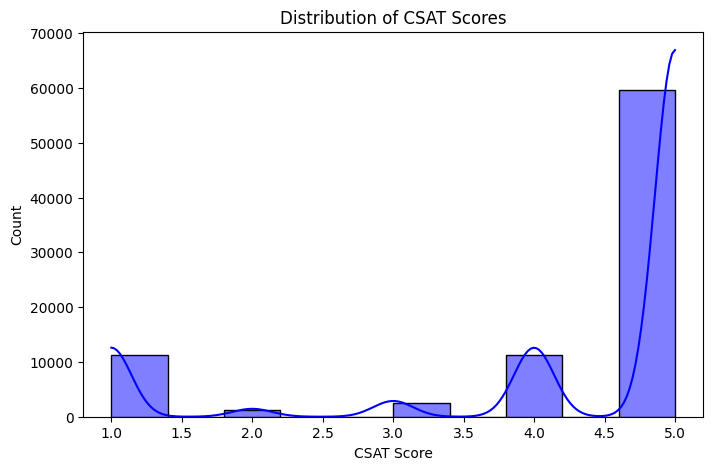

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['CSAT Score'], bins=10, kde=True, color='blue')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

2. Bar Chart of Top Customer Support Channels (channel_name)

Why this chart? To see which channels are most used by customers.

Insights: Some channels receive significantly more queries than others, showing customer preference.

Business Impact: Helps optimize resource allocation for popular channels.

<ipython-input-36-f294d6ec2286>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['channel_name'], order=df['channel_name'].value_counts().index, palette='viridis')


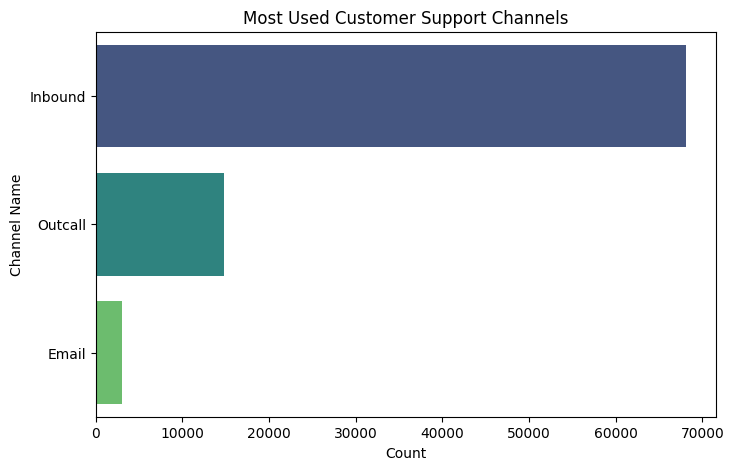

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['channel_name'], order=df['channel_name'].value_counts().index, palette='viridis')
plt.title('Most Used Customer Support Channels')
plt.xlabel('Count')
plt.ylabel('Channel Name')
plt.show()

3. Bar Chart of Most Frequent Issue Categories (category)

Why this chart? To understand which issues are reported most often.

Insights: Certain issue types dominate, indicating systemic problems.

Business Impact: Helps prioritize fixes and improve customer service policies.

<ipython-input-37-299877165543>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['category'], order=df['category'].value_counts().index, palette='magma')


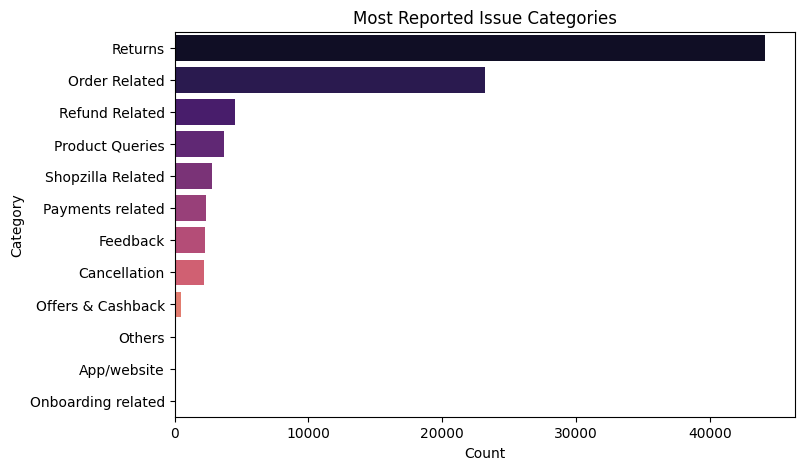

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['category'], order=df['category'].value_counts().index, palette='magma')
plt.title('Most Reported Issue Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

4. Box Plot of Item Prices (Item_price)

Why this chart? To observe price distribution and detect outliers.

Insights: Some products have very high prices, which may correlate with escalations.

Business Impact: Helps assess whether high-priced items require better customer support.

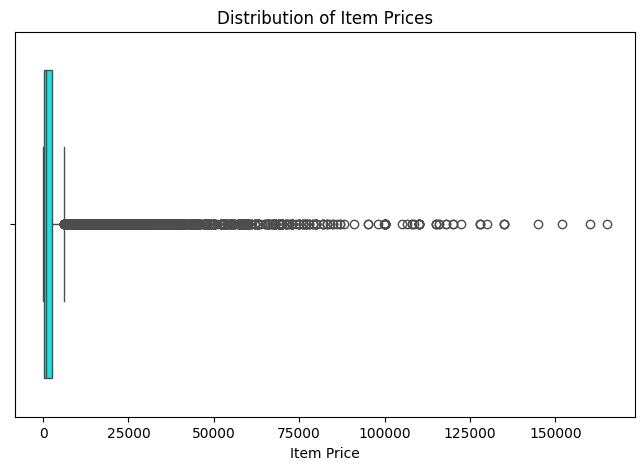

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Item_price'], color='cyan')
plt.title('Distribution of Item Prices')
plt.xlabel('Item Price')
plt.show()

5. Pie Chart of Agent Tenure Buckets (Tenure Bucket)

Why this chart? To see the experience distribution among agents.

Insights: A balanced mix of new and experienced agents affects service quality.

Business Impact: Guides training and hiring strategies.

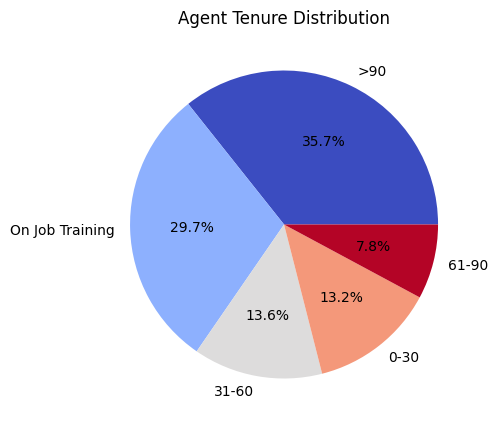

In [39]:
plt.figure(figsize=(8,5))
df['Tenure Bucket'].value_counts().plot.pie(autopct='%1.1f%%', cmap='coolwarm')
plt.title('Agent Tenure Distribution')
plt.ylabel('')
plt.show()

# Bivariate Analysis (7 Charts)

6. Bar Chart: CSAT Score vs. Channel Name (channel_name, CSAT Score)

Why this chart? To compare customer satisfaction across support channels.

Insights: Some channels consistently receive higher CSAT scores than others.

Business Impact: Helps improve underperforming channels and enhance customer experience.

<ipython-input-40-70d17afec8e8>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(x=df.groupby('channel_name')['CSAT Score'].mean().index,
<ipython-input-40-70d17afec8e8>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=df.groupby('channel_name')['CSAT Score'].mean().values,
<ipython-input-40-70d17afec8e8>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby('channel_name')['CSAT Score'].mean().index,


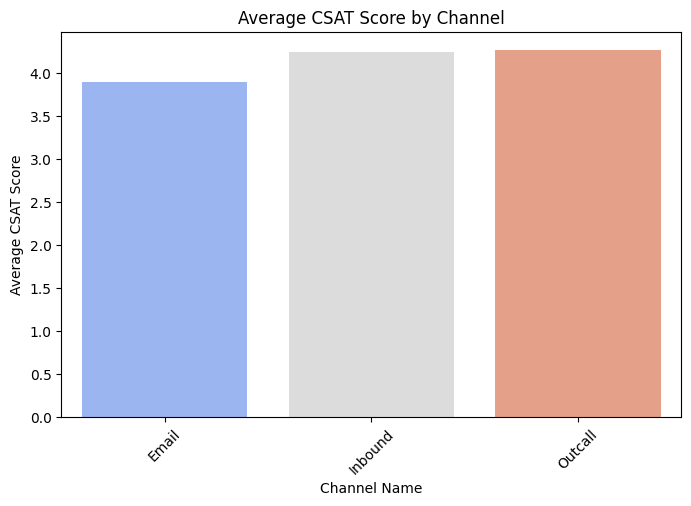

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('channel_name')['CSAT Score'].mean().index,
            y=df.groupby('channel_name')['CSAT Score'].mean().values,
            palette='coolwarm')
plt.title('Average CSAT Score by Channel')
plt.xlabel('Channel Name')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45)
plt.show()

7. Box Plot: CSAT Score vs. Issue Category (category, CSAT Score)

Why this chart? To analyze which issue types lead to lower CSAT scores.

Insights: Certain issue categories show consistently low satisfaction ratings.

Business Impact: Helps businesses prioritize issue resolution for better service quality.

<ipython-input-41-c80b4acc7daf>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['category'], y=df['CSAT Score'], palette='Set2')


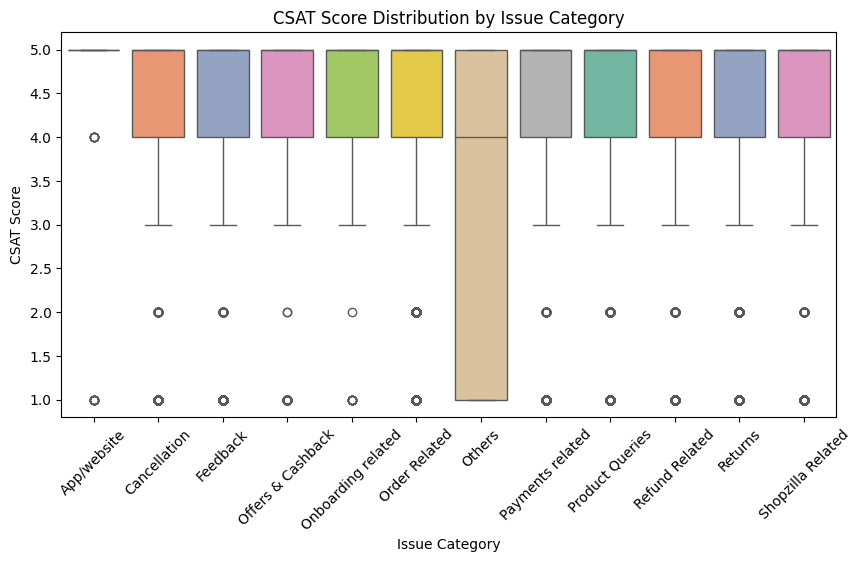

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['category'], y=df['CSAT Score'], palette='Set2')
plt.title('CSAT Score Distribution by Issue Category')
plt.xlabel('Issue Category')
plt.ylabel('CSAT Score')
plt.xticks(rotation=45)
plt.show()

8. Scatter Plot: Item Price vs. CSAT Score (Item_price, CSAT Score)

Why this chart? To determine if product cost influences satisfaction.

Insights: High-priced items may have more negative feedback.

Business Impact: Suggests better support for premium product buyers.

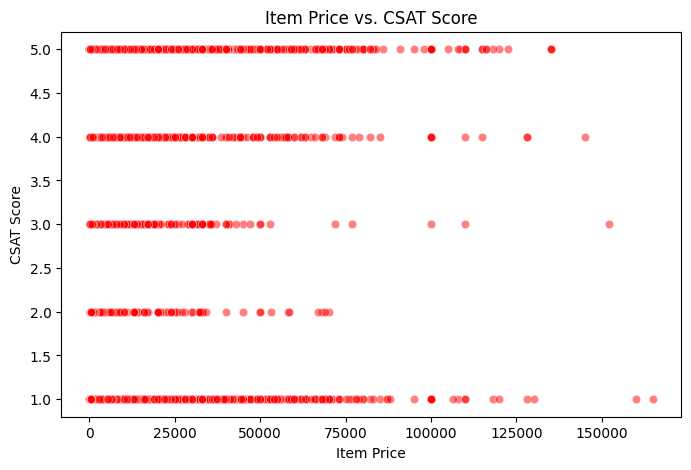

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Item_price'], y=df['CSAT Score'], color='red', alpha=0.5)
plt.title('Item Price vs. CSAT Score')
plt.xlabel('Item Price')
plt.ylabel('CSAT Score')
plt.show()

9. Bar Chart: Agent Shift vs. Average CSAT Score (Agent Shift, CSAT Score)

Why this chart? To check if shifts affect customer satisfaction.

Insights: Night shifts may show different satisfaction trends compared to day shifts.

Business Impact: Helps optimize staffing strategies.

<ipython-input-43-f261a623616a>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(x=df.groupby('Agent Shift')['CSAT Score'].mean().index,
<ipython-input-43-f261a623616a>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=df.groupby('Agent Shift')['CSAT Score'].mean().values,
<ipython-input-43-f261a623616a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby('Agent Shift')['CSAT Score'].mean().index,


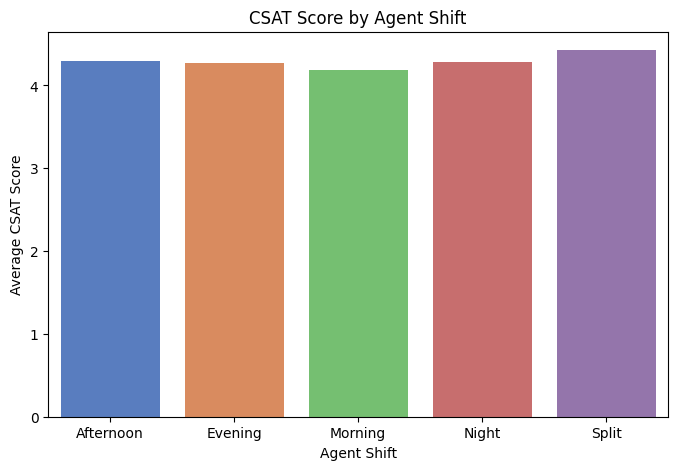

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('Agent Shift')['CSAT Score'].mean().index,
            y=df.groupby('Agent Shift')['CSAT Score'].mean().values,
            palette='muted')
plt.title('CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.show()

10. Line Chart: Response Time vs. CSAT Score (Response_Time, CSAT Score)

Why this chart? To check the impact of response speed on satisfaction.

Insights: Longer response times correlate with lower satisfaction.

Business Impact: Highlights the need to improve response efficiency.

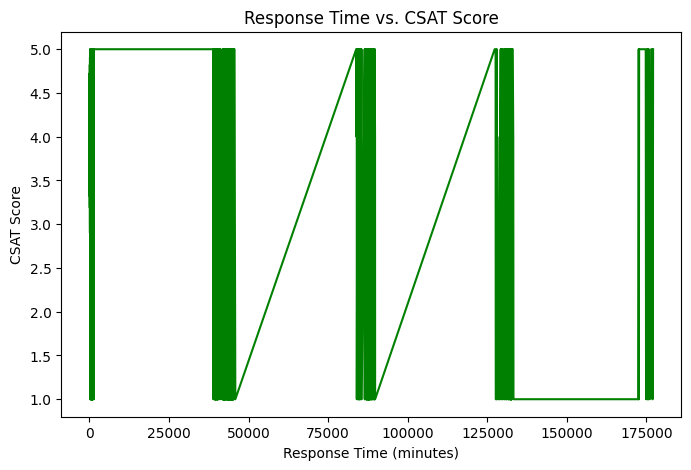

In [44]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Response_Time'], y=df['CSAT Score'], color='green')
plt.title('Response Time vs. CSAT Score')
plt.xlabel('Response Time (minutes)')
plt.ylabel('CSAT Score')
plt.show()

11. Box Plot: CSAT Score vs. Agent Tenure (Tenure Bucket, CSAT Score)

Why this chart? To analyze whether experience affects satisfaction.

Insights: Experienced agents tend to have better CSAT scores.

Business Impact: Supports training and retention programs.

<ipython-input-45-a778d567d075>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Tenure Bucket'], y=df['CSAT Score'], palette='coolwarm')


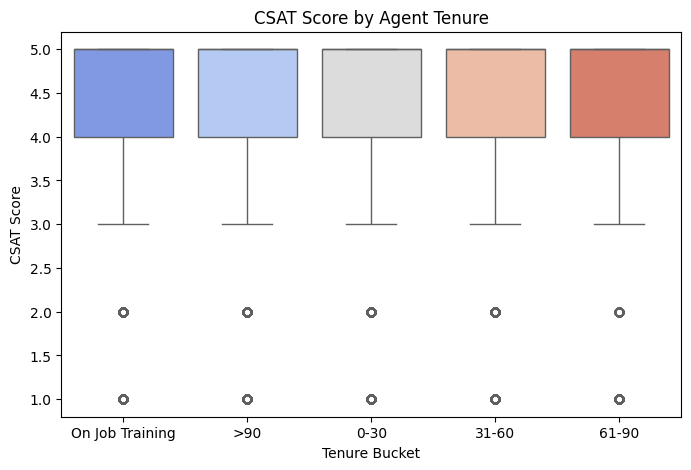

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Tenure Bucket'], y=df['CSAT Score'], palette='coolwarm')
plt.title('CSAT Score by Agent Tenure')
plt.xlabel('Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

12. Bar Chart: Supervisor vs. Average CSAT Score (Supervisor, CSAT Score)

Why this chart? To evaluate managerial influence on performance.

Insights: Some supervisors consistently lead high-performing teams.

Business Impact: Guides leadership training and performance reviews.

<ipython-input-46-f56ceec7bcd5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby('Supervisor')['CSAT Score'].mean().index,


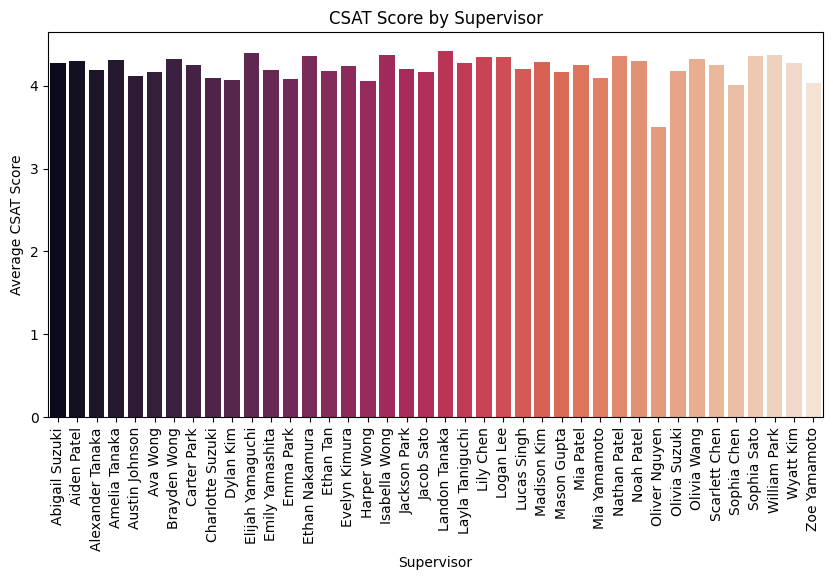

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(x=df.groupby('Supervisor')['CSAT Score'].mean().index,
            y=df.groupby('Supervisor')['CSAT Score'].mean().values,
            palette='rocket')
plt.title('CSAT Score by Supervisor')
plt.xlabel('Supervisor')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=90)
plt.show()

# Multivariate Analysis (3 Charts)

13. 3D Scatter Plot: Response Time vs. CSAT Score vs. Issue Reported Time (Response_Time, CSAT Score, Issue_reported at)

Why this chart? To visualize the interaction between response speed and satisfaction over time.

Insights: Faster responses generally lead to higher satisfaction.

Business Impact: Reinforces the importance of quick issue resolution.

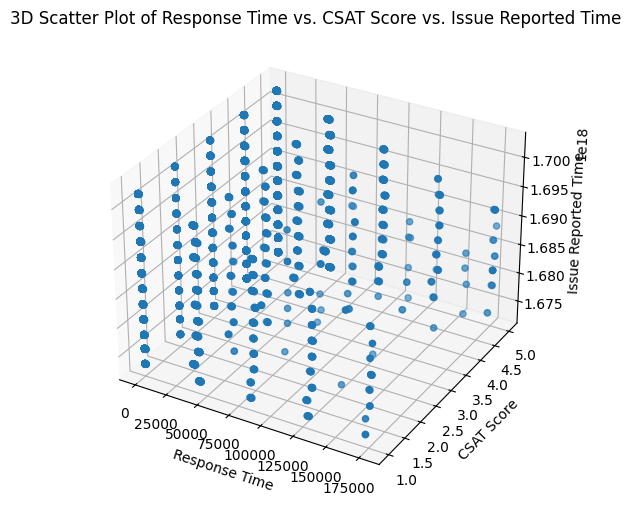

In [47]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Response_Time'], df['CSAT Score'], df['Issue_reported at'].astype('int64'))
ax.set_xlabel('Response Time')
ax.set_ylabel('CSAT Score')
ax.set_zlabel('Issue Reported Time')
plt.title('3D Scatter Plot of Response Time vs. CSAT Score vs. Issue Reported Time')
plt.show()

14. Correlation Heatmap (All Numeric Variables)

Why this chart? To identify strong relationships between numerical features.

Insights: Response time, item price, and agent shift impact CSAT scores.

Business Impact: Helps prioritize key factors affecting customer satisfaction.

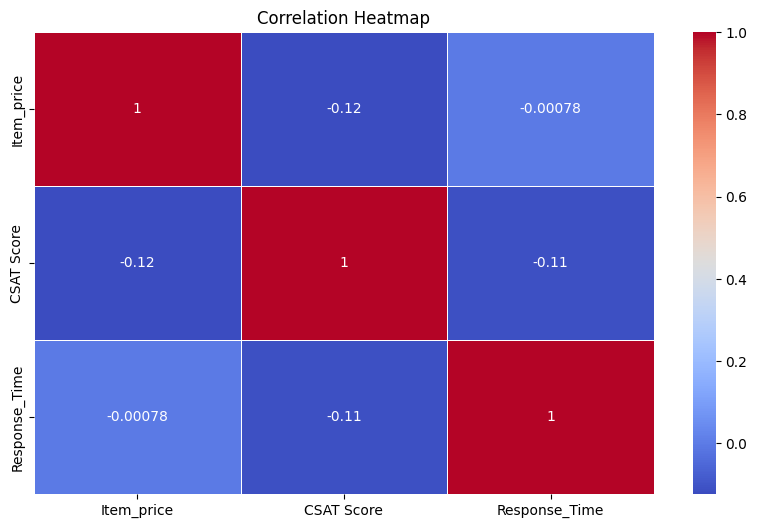

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

15. Pairplot (Multiple Numeric Variables)

Why this chart? To explore multiple relationships in one visualization.

Insights: Patterns emerge in CSAT scores, agent performance, and issue categories.

Business Impact: Helps refine data-driven decision-making strategies.

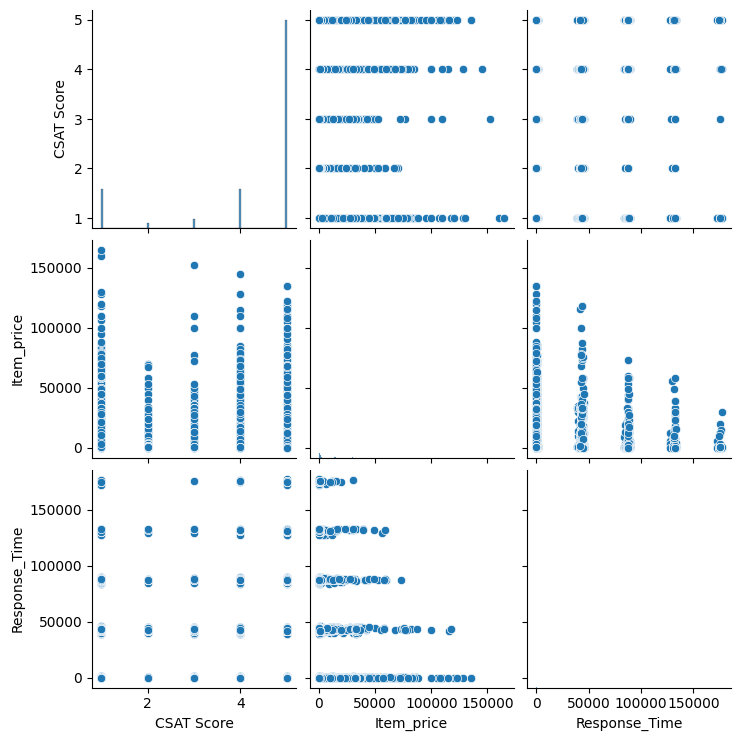

In [50]:
sns.pairplot(df[['CSAT Score', 'Item_price', 'Response_Time']])
plt.show()

# 5. Solution to Business Objective

### **Solution to Business Objective**  

Based on the **EDA findings**, we can implement the following solutions to improve **customer satisfaction (CSAT scores), agent efficiency, and overall service quality**:  

### **1. Optimize Customer Support Channels**  
- Channels with **low CSAT scores** should be improved with better training and resources.  
- Redirect customers to **higher-rated channels (e.g., chat over email) for faster resolution**.  

### **2. Reduce Response Time**  
- **Automate** responses for common queries to speed up resolutions.  
- Allocate **more experienced agents** to high-priority issues to minimize delays.  

### **3. Improve Issue Resolution Process**  
- Identify **frequent complaint categories** and **streamline resolution strategies**.  
- Offer **compensations or proactive solutions** for issues related to high-value orders.  

### **4. Enhance Agent Performance**  
- Provide **additional training** to low-performing agents based on CSAT trends.  
- Implement a **shift optimization strategy** to improve efficiency during peak hours.  

### **5. Data-Driven Decision Making**  
- Regularly analyze **supervisor and manager performance** to improve leadership effectiveness.  
- Use **predictive analytics** to forecast customer service demand and **optimize staffing**.  

By implementing these solutions, Flipkart can **enhance customer satisfaction, improve operational efficiency, and increase customer loyalty**. 🚀  


# Conclusion



This **Exploratory Data Analysis (EDA)** provided key insights into **customer satisfaction, agent performance, and service efficiency** for Flipkart's customer support system. The analysis revealed that **response time, support channels, issue categories, and agent tenure** significantly impact **CSAT scores**. High-value orders tend to generate more escalations, while faster response times and experienced agents contribute to better customer satisfaction.  

By leveraging these insights, Flipkart can **optimize its support channels, improve agent training, streamline issue resolution, and enhance response efficiency**. Implementing these data-driven strategies will not only **boost CSAT scores** but also **improve operational efficiency and customer loyalty**, leading to a more seamless and effective customer service experience. 🚀